## Example for pairing OMPS NM O3 data with UFS-Chem

This example will demonstrate how to use MELODIES MONET to pair model output (UFS-Chem, gfs.t00z.atmf*nc output files) with OMPS NM O3 observatiions from Suomi NPP obtained from NASA (https://doi.org/10.5067/0WF4HAAZ0VHK). 

Pairing satellite data is memory and compute intensive, so it is recommended that users processing longer time periods "time-chunk" their analysis period into smaller subsets and save the paired data for each sub-window as a netcdf. Users can then read these files back into MELODIES MONET to create plots or calculate statistics or use this paired data output file to do their own analysis.

### First we import the driver from MELODIES-MONET.

In [1]:
from melodies_monet import driver

### Second we initialize the driver and read in a control file

In [2]:
an = driver.analysis()
an.control = '../yaml/control_omps_nm_o3.yaml'
an.read_control()

### Then, we read in and pair the data

Currently the OMPS NM O3 pairing methods return the paired dataset on the observation grid. This will later be changed to return the paired satellite and model aggregated onto the original model grid. 

In [3]:
an.open_obs()
an.open_models()
an.pair_data()

Reading OMPS_NM
/wrk/da12/mbruckner/omps/OMPS-NPP_NMTO3-L2_v2.1_2023m0805t063202_o60991_2023m0805t101524.h5
/wrk/da12/mbruckner/omps/OMPS-NPP_NMTO3-L2_v2.1_2023m0805t081331_o60992_2023m0805t101523.h5
/wrk/da12/mbruckner/omps/OMPS-NPP_NMTO3-L2_v2.1_2023m0805t095501_o60993_2023m0805t115128.h5
/wrk/da12/mbruckner/omps/OMPS-NPP_NMTO3-L2_v2.1_2023m0805t113631_o60994_2023m0805t132821.h5
/wrk/da12/mbruckner/omps/OMPS-NPP_NMTO3-L2_v2.1_2023m0805t131800_o60995_2023m0805t164700.h5
/wrk/da12/mbruckner/omps/OMPS-NPP_NMTO3-L2_v2.1_2023m0805t145930_o60996_2023m0805t182116.h5
ufschem
/wrk/da12/mbruckner/ufschem/gfs.20230805/gfs.t00z.atmf*.nc
**** Reading UFS-AQM model output...


/home/mbruckner/MELODIES_MONET/monetio/monetio/models/ufs.py:157: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  dset = xr.open_mfdataset(fname, concat_dim="time", combine="nested", **kwargs)[var_list]


1, in pair data
pairing with averaging kernel application


/home/mbruckner/MELODIES_MONET/MELODIES-MONET/melodies_monet/util/satellite_utilities.py:360: UserWarning: Observations does not contain data for <xarray.DataArray 'floor' ()> Size: 8B
array('2023-08-06T00:00:00.000000000', dtype='datetime64[ns]')
Coordinates:
    time     datetime64[ns] 8B 2023-08-06T13:30:00, skipping.
  warnings.warn(f'Observations does not contain data for {day}, skipping.')
/home/mbruckner/miniconda3/envs/melodies_dev/lib/python3.11/site-packages/dask/core.py:133: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
/home/mbruckner/miniconda3/envs/melodies_dev/lib/python3.11/site-packages/dask/core.py:133: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))


### Aggregating paired dataset from satellite space to model grid

As the horizontal resolution of the swath data is significantly higher than the model resolution, the paired observations should be averaged onto the model grid in order to lessen the representativeness error. If this is not done the model-obs comparison will unfairly include features that the model is unable to capture. 

In [4]:
import numpy as np
from pyresample import AreaDefinition, SwathDefinition
from pyresample.bucket import BucketResampler
import pandas as pd
import xarray as xr

In [5]:
model_grid = AreaDefinition.from_area_of_interest('UFS_c96_grid',{'proj':'latlon','datum':"WGS84"},
                                                 shape=(an.models['ufschem'].obj.sizes['y'],an.models['ufschem'].obj.sizes['x']),
                                                 center=(0,0),resolution=1,units='deg',
                                                 lons=an.models['ufschem'].obj.longitude.values,lats=an.models['ufschem'].obj.latitude.values)
newlon,newlat = model_grid.get_lonlats()
ny,nx = newlon.shape
paired_data_varnames = list(an.paired['omps_nm_ufschem'].obj.keys())
days = np.unique(an.paired['omps_nm_ufschem'].obj.time.dt.floor("D"))
nt, = days.shape

paired_dtime = an.paired['omps_nm_ufschem'].obj['time'].dt.floor('D')

In [6]:
paired_on_modgrid = xr.Dataset({k: (['time','y','x'],np.zeros((nt,ny,nx),dtype='float32')) for k in paired_data_varnames},
                               coords={'latitude':(['y','x'],newlat),"longitude":(['y','x'],newlon),"time": (['time'],days)})
for d, day in enumerate(days):
    paired_day = an.paired['omps_nm_ufschem'].obj.where(paired_dtime == days[0],drop=True)
    swath_def = SwathDefinition(lons=paired_day.longitude, lats=paired_day.latitude)
    lons,lats = swath_def.get_lonlats(chunks=1)
    
    resampler = BucketResampler(model_grid,lons,lats)
    
    for k in paired_data_varnames:
        sumkey = resampler.get_sum(paired_day[k])
        countkey = resampler.get_sum(np.logical_not(np.isnan(paired_day[k])).astype(int))
        #sumkey.compute()
        #countkey.compute()
        paired_on_modgrid[k].loc[dict(time=day)] = sumkey/countkey

/home/mbruckner/miniconda3/envs/melodies_dev/lib/python3.11/site-packages/pyproj/crs/crs.py:1295: UserWarning: You will likely lose important projection information when converting to a PROJ string from another format. See: https://proj.org/faq.html#what-is-the-best-format-for-describing-coordinate-reference-systems
  proj = self._crs.to_proj4(version=version)


### Using Melodies Monet plotting for post-processed paired dataset 

The Melodies Monet plotting and stats tools can be used on the custom processed paired dataset by feeding this dataset into a paired class instance. 

-127.0 127.0
Reference std: 31.08832


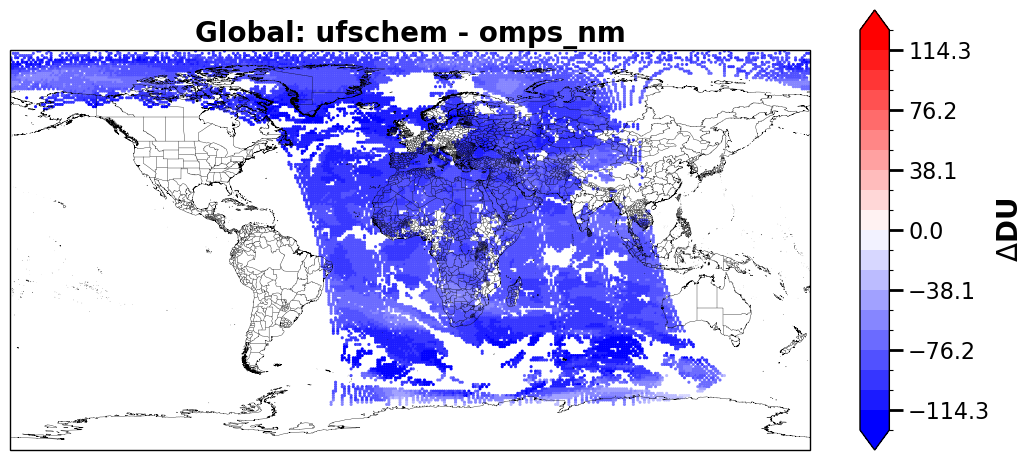

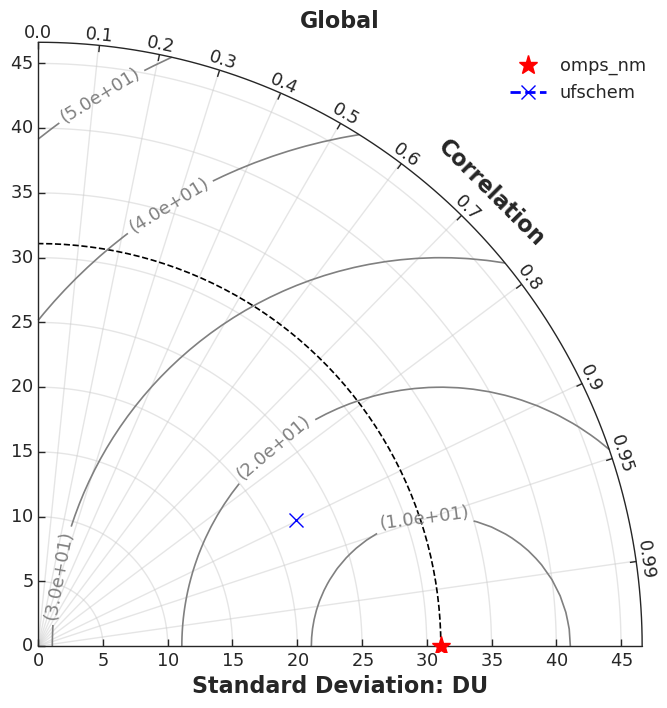

In [7]:
an.paired['omps_nm_ufschem'].obj = paired_on_modgrid

an.plotting()